### Workflow for K-fold CV

In [1]:
import pandas as pd
import numpy as np, networkx as nx, gudhi_persistence as gp, watts_model as nwm
import matplotlib.pyplot as plt, utilsA1 as utils
import os, importlib

from lifelines.utils import concordance_index
from sklearn.decomposition import PCA
from lifelines import CoxTimeVaryingFitter


In [29]:
def validation_loop(params_list):
    df, _ = nwm.main_sims(params_list = params_list, save_files = False)
    df, _ = utils.clean_simulation_df(df,
                                    group_cols=['simulation_id', 'realization_id'],
                                    front_cols=front_cols,
                                    suffix_prefixes=['H', 'L', 'I', 'E'])
    df = utils.compute_pca_features(df, feature_cols, base_cols, n_components=5)
    df = utils.prep_for_cox_tv(df,
                                     group_cols=['simulation_id', 'realization_id'],
                                     state_col='state',
                                     landscape_prefixes=['L'],
                                     image_prefixes=['I'],
                                     essential_prefixes=['E'])
    cindex_mean = utils.cvt_validation_score(df, k = 5)
    return cindex_mean

In [54]:

num_samples = 20

param_generation_rng = np.random.default_rng(444)
params_list = []
for _ in range(num_samples):
    num_nodes = param_generation_rng.choice([20])
    weighted = True
    n_seeds = param_generation_rng.choice([2])
    node_active_threshold = param_generation_rng.choice([0.02, 0.025, 0.03, 0.1])
    num_neighbor_nodes = param_generation_rng.choice([3, 4])
    distance_threshold = param_generation_rng.integers(num_neighbor_nodes + 1, num_neighbor_nodes + 2)
    total_random_edges = param_generation_rng.choice([20, 30, 40])
    upper_weight_limit = param_generation_rng.choice([10, 20])
    skew_power = param_generation_rng.choice([2, 4])
    seed_cluster_distance = 15
    ngeom_edges_in_persistence = False
    max_persistence_dim = 2
    threshold_sum = sum(range(num_nodes))
    seeding_method = 'all_combinations'
    ngeo_placement = 'random.choice'
    calculate_representation = True
    bandwidth = param_generation_rng.choice([0.01, 0.02, 0.05, 0.1, 0.2, 0.25, 0.5, 0.8, 1.0, 2.0])
    representation_choice_function= param_generation_rng.choice(['persistence', 'birth', 'death', 'max', 'arctan'])
    param = {
        'num_nodes': num_nodes,  # fixed
        'num_neighbor_nodes': num_neighbor_nodes,
        'total_random_edges': total_random_edges,
        'distance_threshold': distance_threshold,
        'weighted': weighted,
        'ngeo_placement': ngeo_placement,  # other 'ngeo_per_node'
        'n_seeds': n_seeds,
        'node_active_threshold': node_active_threshold,
        'upper_weight_limit': upper_weight_limit,
        'skew_power': skew_power,
        'seed_cluster_distance': seed_cluster_distance,
        'ngeom_edges_in_persistence': ngeom_edges_in_persistence,
        'max_persistence_dim': max_persistence_dim,
        'threshold_sum': threshold_sum,
        'seeding_method': seeding_method,
        'calculate_representation': calculate_representation,
        'bandwidth': bandwidth,
        'representation_choice_function': representation_choice_function
    }

    params_list.append(param)

param_df = pd.DataFrame(params_list)
param_df


,num_nodes,num_neighbor_nodes,total_random_edges,distance_threshold,weighted,ngeo_placement,n_seeds,node_active_threshold,upper_weight_limit,skew_power,seed_cluster_distance,ngeom_edges_in_persistence,max_persistence_dim,threshold_sum,seeding_method,calculate_representation,bandwidth,representation_choice_function
0,20,4,30,5,True,random.choice,2,0.030,10,2,15,False,2,190,all_combinations,True,0.80,birth
1,20,3,30,4,True,random.choice,2,0.100,10,4,15,False,2,190,all_combinations,True,0.05,persistence
2,20,3,20,4,True,random.choice,2,0.020,10,2,15,False,2,190,all_combinations,True,0.80,birth
3,20,3,20,4,True,random.choice,2,0.100,20,2,15,False,2,190,all_combinations,True,0.02,death
4,20,3,20,4,True,random.choice,2,0.020,20,2,15,False,2,190,all_combinations,True,1.00,birth
5,20,3,20,4,True,random.choice,2,0.100,20,4,15,False,2,190,all_combinations,True,0.80,birth
6,20,4,20,5,True,random.choice,2,0.020,10,2,15,False,2,190,all_combinations,True,0.20,arctan
7,20,4,30,5,True,random.choice,2,0.025,10,4,15,False,2,190,all_combinations,True,0.50,birth
8,20,3,40,4,True,random.choice,2,0.020,20,2,15,False,2,190,all_combinations,True,2.00,arctan
9,20,3,20,4,True,random.choice,2,0.020,20,4,15,False,2,190,all_combinations,True,0.05,death


In [68]:
importlib.reload(nwm)
importlib.reload(gp)
importlib.reload(utils)

front_cols = ["simulation_id", "realization_id", "time", "state",
              "node_active_threshold", "num_nodes", "num_neighbor_nodes",
              "total_random_edges", "num_active_nodes", "active_nodes"]
base_cols = ['simulation_id', 'realization_id', 'time', 'state', 'E_0']
feature_cols = ['L_0', 'L_1', 'L_2', 'I_0', 'I_1', 'I_2']
bandwidth_grid = [0.01, 0.02, 0.05, 0.1, 0.2, 0.25, 0.5, 0.8, 1.0, 2.0, 5.0]
representation_choice_function_grid = ['persistence', 'birth', 'arctan']
bandwidth_grid = [0.0001, 0.001, 0.01, 0.1, 0.5, 1.0, 2.0]

In [78]:
validation_results = []
surface_fun = "persistence"
bandwidth = 0.001 #for bandwidth in bandwidth_grid:
print(f"Simulation and validation for: surface_fun={surface_fun}, bandwidth={bandwidth}")
params_list[0]['representation_choice_function'] = surface_fun
params_list[0]['bandwidth'] = bandwidth
cindex_mean = validation_loop(params_list)
validation_results.append({
    "bandwidth": bandwidth,
    "surface_function": surface_fun,
    "cv_concordance": cindex_mean
})

Simulation and validation for: surface_fun=persistence, bandwidth=0.001
Simulating Contagion Map for simulation: 0/20
Simulating Contagion Map for simulation: 1/20
Simulating Contagion Map for simulation: 2/20
Simulating Contagion Map for simulation: 3/20
Simulating Contagion Map for simulation: 4/20
Simulating Contagion Map for simulation: 5/20
Simulating Contagion Map for simulation: 6/20
Simulating Contagion Map for simulation: 7/20
Simulating Contagion Map for simulation: 8/20
Simulating Contagion Map for simulation: 9/20
Simulating Contagion Map for simulation: 10/20
Simulating Contagion Map for simulation: 11/20
Simulating Contagion Map for simulation: 12/20
Simulating Contagion Map for simulation: 13/20
Simulating Contagion Map for simulation: 14/20
Simulating Contagion Map for simulation: 15/20
Simulating Contagion Map for simulation: 16/20
Simulating Contagion Map for simulation: 17/20
Simulating Contagion Map for simulation: 18/20
Simulating Contagion Map for simulation: 19/2

C:\Users\sranasin\PycharmProjects\NetworkModels\Project1\A1\utilsA1.py:412: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[feature_cols] = df[feature_cols].applymap(


In [79]:
validation_results_df = pd.DataFrame(validation_results)
validation_results_df

,bandwidth,surface_function,cv_concordance
0,0.001,persistence,0.649282


In [32]:
best = validation_results_df.loc[validation_results_df["cv_concordance"].idxmax()]
print("Best Hyperparameter for Bandwidth:", best['bandwidth'], "with concordance of ", best['cv_concordance'])

Best Hyperparameter for Bandwidth: 2.0 with concordance of  0.694469239270201


In [33]:
bandwidth = best['bandwidth']
validation_results2 = []
for surface_fun in representation_choice_function_grid:
    print(f"Simulation and validation for: surface_fun={surface_fun}, bandwidth={bandwidth}")
    params_list[0]['representation_choice_function'] = surface_fun
    params_list[0]['bandwidth'] = bandwidth
    cindex_mean = validation_loop(params_list)
    validation_results2.append({
        "bandwidth": bandwidth,
        "surface_function": surface_fun,
        "cv_concordance": cindex_mean
    })


validation_results_df2 = pd.DataFrame(validation_results2)
best2 = validation_results_df2.loc[validation_results_df2["cv_concordance"].idxmax()]
print("Best Hyperparameter for weight function: ", best['surface_function'], "with concordance of ", best['cv_concordance'])

Simulation and validation for: surface_fun=persistence, bandwidth=2.0
Simulating Contagion Map for simulation: 0/20

Simulating Contagion Map for simulation: 1/20

Simulating Contagion Map for simulation: 2/20

Simulating Contagion Map for simulation: 3/20

Simulating Contagion Map for simulation: 4/20

Simulating Contagion Map for simulation: 5/20

Simulating Contagion Map for simulation: 6/20

Simulating Contagion Map for simulation: 7/20

Simulating Contagion Map for simulation: 8/20

Simulating Contagion Map for simulation: 9/20

Simulating Contagion Map for simulation: 10/20

Simulating Contagion Map for simulation: 11/20

Simulating Contagion Map for simulation: 12/20

Simulating Contagion Map for simulation: 13/20

Simulating Contagion Map for simulation: 14/20

Simulating Contagion Map for simulation: 15/20

Simulating Contagion Map for simulation: 16/20

Simulating Contagion Map for simulation: 17/20

Simulating Contagion Map for simulation: 18/20

Simulating Contagion Map for

C:\Users\sranasin\PycharmProjects\NetworkModels\Project1\A1\utilsA1.py:412: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[feature_cols] = df[feature_cols].applymap(


Simulation and validation for: surface_fun=birth, bandwidth=2.0
Simulating Contagion Map for simulation: 0/20

Simulating Contagion Map for simulation: 1/20

Simulating Contagion Map for simulation: 2/20

Simulating Contagion Map for simulation: 3/20

Simulating Contagion Map for simulation: 4/20

Simulating Contagion Map for simulation: 5/20

Simulating Contagion Map for simulation: 6/20

Simulating Contagion Map for simulation: 7/20

Simulating Contagion Map for simulation: 8/20

Simulating Contagion Map for simulation: 9/20

Simulating Contagion Map for simulation: 10/20

Simulating Contagion Map for simulation: 11/20

Simulating Contagion Map for simulation: 12/20

Simulating Contagion Map for simulation: 13/20

Simulating Contagion Map for simulation: 14/20

Simulating Contagion Map for simulation: 15/20

Simulating Contagion Map for simulation: 16/20

Simulating Contagion Map for simulation: 17/20

Simulating Contagion Map for simulation: 18/20

Simulating Contagion Map for simul

C:\Users\sranasin\PycharmProjects\NetworkModels\Project1\A1\utilsA1.py:412: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[feature_cols] = df[feature_cols].applymap(


Simulation and validation for: surface_fun=arctan, bandwidth=2.0
Simulating Contagion Map for simulation: 0/20

Simulating Contagion Map for simulation: 1/20

Simulating Contagion Map for simulation: 2/20

Simulating Contagion Map for simulation: 3/20

Simulating Contagion Map for simulation: 4/20

Simulating Contagion Map for simulation: 5/20

Simulating Contagion Map for simulation: 6/20

Simulating Contagion Map for simulation: 7/20

Simulating Contagion Map for simulation: 8/20

Simulating Contagion Map for simulation: 9/20

Simulating Contagion Map for simulation: 10/20

Simulating Contagion Map for simulation: 11/20

Simulating Contagion Map for simulation: 12/20

Simulating Contagion Map for simulation: 13/20

Simulating Contagion Map for simulation: 14/20

Simulating Contagion Map for simulation: 15/20

Simulating Contagion Map for simulation: 16/20

Simulating Contagion Map for simulation: 17/20

Simulating Contagion Map for simulation: 18/20

Simulating Contagion Map for simu

C:\Users\sranasin\PycharmProjects\NetworkModels\Project1\A1\utilsA1.py:412: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[feature_cols] = df[feature_cols].applymap(


Best Hyperparameter for weight function:  persistence with concordance of  0.694469239270201


In [82]:
importlib.reload(nwm)
importlib.reload(gp)
importlib.reload(utils)

params_list[0]['bandwidth'] = 0.5
params_list[0]['representation_choice_function'] = 'persistence'

df, _ = nwm.main_sims(params_list = params_list, save_files = False)
df, _ = utils.clean_simulation_df(df,
                                group_cols=['simulation_id', 'realization_id'],
                                front_cols=front_cols,
                                suffix_prefixes=['H', 'L', 'I', 'E'])
df = utils.compute_pca_features(df, feature_cols, base_cols, n_components=5)
df = utils.prep_for_cox_tv(df,
                                 group_cols=['simulation_id', 'realization_id'],
                                 state_col='state',
                                 landscape_prefixes=['L'],
                                 image_prefixes=['I'],
                                 essential_prefixes=['E'])

ctv = CoxTimeVaryingFitter()
ctv.fit(df, id_col="id", start_col="start", stop_col="stop", event_col="state")
ctv.print_summary()


Simulating Contagion Map for simulation: 0/20
Simulating Contagion Map for simulation: 1/20
Simulating Contagion Map for simulation: 2/20
Simulating Contagion Map for simulation: 3/20
Simulating Contagion Map for simulation: 4/20
Simulating Contagion Map for simulation: 5/20
Simulating Contagion Map for simulation: 6/20
Simulating Contagion Map for simulation: 7/20
Simulating Contagion Map for simulation: 8/20
Simulating Contagion Map for simulation: 9/20
Simulating Contagion Map for simulation: 10/20
Simulating Contagion Map for simulation: 11/20
Simulating Contagion Map for simulation: 12/20
Simulating Contagion Map for simulation: 13/20
Simulating Contagion Map for simulation: 14/20
Simulating Contagion Map for simulation: 15/20
Simulating Contagion Map for simulation: 16/20
Simulating Contagion Map for simulation: 17/20
Simulating Contagion Map for simulation: 18/20
Simulating Contagion Map for simulation: 19/20


C:\Users\sranasin\PycharmProjects\NetworkModels\Project1\A1\utilsA1.py:412: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[feature_cols] = df[feature_cols].applymap(


<lifelines.CoxTimeVaryingFitter: fitted with 16806 periods, 3600 subjects, 3600 events>
         event col = 'state'
number of subjects = 3600
 number of periods = 16806
  number of events = 3600
partial log-likelihood = -25661.55
  time fit was run = 2025-09-23 08:42:09 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
L_0_PC1   -0.06      0.94      0.02           -0.11           -0.02                0.90                0.98
L_0_PC2    0.22      1.24      0.03            0.16            0.28                1.17                1.32
L_0_PC3    0.80      2.23      0.06            0.69            0.92                1.99                2.51
L_0_PC4    0.11      1.11      0.06           -0.02            0.23                0.98                1.26
L_0_PC5    0.41      1.51      0.07            0.27            0.55                1.31                1.74
I_0_PC1   -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
I_0_PC2   -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
I_0_PC3   -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
I_0_PC4   -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
I_0_PC5   -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
E_0       -0.06      0.94      0.01           -0.08           -0.04                0.92                0.96

           cmp to     z      p  -log2(p)
covariate                               
L_0_PC1      0.00 -2.95 <0.005      8.31
L_0_PC2      0.00  6.99 <0.005     38.41
L_0_PC3      0.00 13.51 <0.005    135.74
L_0_PC4      0.00  1.68   0.09      3.41
L_0_PC5      0.00  5.69 <0.005     26.25
I_0_PC1      0.00 -3.03 <0.005      8.67
I_0_PC2      0.00 -7.57 <0.005     44.63
I_0_PC3      0.00 -6.14 <0.005     30.14
I_0_PC4      0.00 -8.65 <0.005     57.38
I_0_PC5      0.00 -3.46 <0.005     10.87
E_0          0.00 -5.04 <0.005     21.03
---
Partial AIC = 51345.11
log-likelihood ratio test = 445.48 on 11 df
-log2(p) of ll-ratio test = 291.93

<Axes: xlabel='log(HR) (95% CI)'>

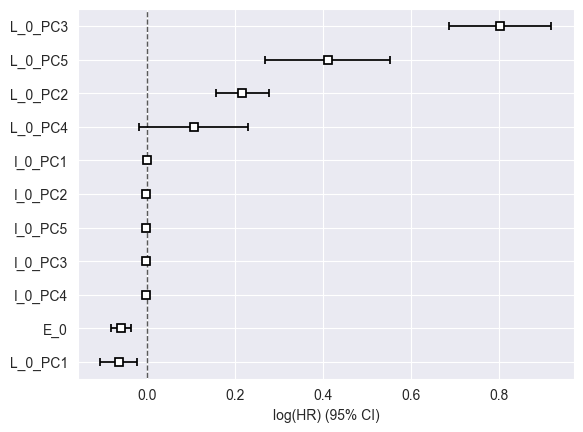

In [83]:
ctv.plot()

In [53]:
risk = ctv.predict_partial_hazard(df)
print(f"Log-likelihood for current Modle: {ctv.log_likelihood_}, with concordance of: {np.mean(concordance_index(df['stop'], -risk, df['state']))}")

Log-likelihood for current Modle: -25618.517613540553, with concordance of: 0.6244612850815918


In [46]:
from lifelines.utils import concordance_index